In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
city = '北京'

In [ ]:
housing = pd.read_csv(f'processed_data/{city}/04_data.csv')

In [ ]:
# fully print
print(housing.columns.tolist())

['城市', '区域', '板块', 'price', 'unit_price', '配备电梯', '挂牌时间', '上次交易', '产权所属', '核心卖点', '户型介绍', '周边配套', '交通出行', 'x', 'y', '年份', 'nearest_park_dist_km', 'nearest_park_index', 'nearest_park_industry', 'log_price', 'log_unit_price', 'area', 'distance_to_center', 'block', 'rooms', 'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看', '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors', 'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层', 'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室', '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北', '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构', '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构', '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装', '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households', 'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排', '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私产', '交易权属_is_商品房', '交易权属_is_已购公房', '交易权属_is_一类经济适用

In [ ]:
stats = housing.drop(columns=['城市', '区域', '板块', '挂牌时间', '上次交易', '核心卖点', '户型介绍', '周边配套', '交通出行'
                              ,'nearest_park_index','nearest_park_industry','x','y'])

In [ ]:
from utils import Display

Display(stats)

Shape: (261159, 92)
Index(['price', 'unit_price', '配备电梯', '产权所属', 'x', 'y', 'nearest_park_dist_km',
       'log_price', 'log_unit_price', 'area', 'distance_to_center', 'block',
       'rooms', 'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看',
       '看房时间_is_下班后可看', '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors',
       'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层',
       'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室',
       '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北',
       '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构',
       '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构',
       '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装',
       '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households',
       'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排',
       '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私产', '交易权属_is_商品房', '交易权属_is_已购公房',
       '交易权属_is_一类经济适用房'

,Missing,Unique,Dtype
price,0,2818,float64
unit_price,0,99366,float64
配备电梯,0,2,int64
产权所属,0,2,int64
x,0,8192,float64
...,...,...,...
category_is_Others,0,2,int64
category_is_High-Tech,0,2,int64
category_is_General-Mfg,0,2,int64
category_is_Heavy-Nuisance,0,2,int64


【col: price】
  - 450.0: 1974 次
  - 550.0: 1686 次
  - 420.0: 1667 次
  - 320.0: 1663 次
  - 330.0: 1647 次
----------------------------------------
【col: unit_price】
  - 100000.0: 112 次
  - 50000.0: 43 次
  - 125000.0: 41 次
  - 45455.0: 39 次
  - 62500.0: 37 次
----------------------------------------
【col: 配备电梯】
  - 1: 148836 次
  - 0: 112323 次
----------------------------------------
【col: 产权所属】
  - 2: 228758 次
  - 1: 32401 次
----------------------------------------
【col: x】
  - 116.247008: 531 次
  - 116.343245: 527 次
  - 116.43942: 523 次
  - 117.273243: 517 次
  - 116.441781: 494 次
----------------------------------------
【col: y】
  - 39.906426: 531 次
  - 39.900529: 527 次
  - 40.072066: 523 次
  - 40.667358: 517 次
  - 39.991956: 494 次
----------------------------------------
【col: nearest_park_dist_km】
  - 1.0558044660826411: 531 次
  - 0.1682971198726757: 527 次
  - 0.2633951853487862: 523 次
  - 12.279585246760934: 517 次
  - 1.251156431953514: 494 次
----------------------------------------
【co

In [ ]:
missing_cols = stats.isnull().sum()
print(missing_cols[missing_cols > 0])

stats = stats.dropna(subset=['年份'])

In [ ]:
from econml.dml import LinearDML
from econml.cate_interpreter import SingleTreeCateInterpreter

Y = stats['log_unit_price']
T = stats['nearest_park_dist_km']


base_cols = ['distance_to_center', 'area','nearest_subway_dist_km','administrative_level','block']
cat_cols = [col for col in stats.columns if col.startswith('category_is_')]
X_cols = base_cols + cat_cols
X = stats[X_cols]


exclude_cols = X_cols + ['log_unit_price', 'nearest_park_dist_km', 'price', 'unit_price', 'log_price']
W_cols = [col for col in stats.columns if col not in exclude_cols]
W = stats[W_cols]


/home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
print(W_cols)
print(X_cols)

['配备电梯',
 '产权所属',
 'x',
 'y',
 'area',
 'rooms',
 'halls',
 'kitchens',
 'bathrooms',
 '看房时间_is_只周末可看',
 '看房时间_is_下班后可看',
 '看房时间_is_提前预约随时可看',
 '看房时间_is_有租户需预约',
 'total_floors',
 'floor_level_is_低楼层',
 'floor_level_is_底层',
 'floor_level_is_高楼层',
 'floor_level_is_中楼层',
 'floor_level_is_顶层',
 'floor_level_is_地下室',
 '房屋朝向_is_南',
 '房屋朝向_is_北',
 '房屋朝向_is_东',
 '房屋朝向_is_西',
 '房屋朝向_is_西北',
 '房屋朝向_is_西南',
 '房屋朝向_is_东南',
 '房屋朝向_is_东北',
 '建筑结构_is_钢混结构',
 '建筑结构_is_混合结构',
 '建筑结构_is_未知结构',
 '建筑结构_is_砖混结构',
 '建筑结构_is_钢结构',
 '建筑结构_is_砖木结构',
 '建筑结构_is_框架结构',
 '装修情况_is_精装',
 '装修情况_is_简装',
 '装修情况_is_毛坯',
 '装修情况_is_其它',
 '装修情况_is_其他',
 'elevators',
 'households',
 'elevators_household_ratio',
 '别墅类型_is_非别墅',
 '别墅类型_is_独栋',
 '别墅类型_is_联排',
 '别墅类型_is_叠拼',
 '别墅类型_is_双拼',
 '交易权属_is_私产',
 '交易权属_is_商品房',
 '交易权属_is_已购公房',
 '交易权属_is_一类经济适用房',
 '交易权属_is_二类经济适用房',
 '交易权属_is_央产房',
 '交易权属_is_限价商品房',
 '交易权属_is_定向安置房',
 '交易权属_is_自住型商品房',
 '房屋用途_is_普通住宅',
 '房屋用途_is_别墅',
 '房屋用途_is_车库',
 '房屋用途_is_商业办公类',
 '房屋用途_is_公寓',
 '

In [ ]:
T_log = np.log1p(T) 

In [ ]:
import optuna
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from xgboost import XGBRegressor

def objective(trial, X_full, y_full):
    # 建议在函数外部完成转换，避免重复消耗时间
    X_np = X_full.values.astype(np.float32) # GPU 喜欢 float32
    y_np = y_full.values.astype(np.float32) if isinstance(y_full, pd.Series) else y_full.astype(np.float32)

    params = {
        'n_estimators': 3000, 
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        
        # --- 针对 GPU 的关键修改 ---
        'tree_method': 'hist',
        'device': 'cuda',       # 确保是 cuda
        'random_state': 42,
        'early_stopping_rounds': 50

    }
    
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []
    
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_np)):
        X_train, X_valid = X_np[train_idx], X_np[valid_idx]
        y_train, y_valid = y_np[train_idx], y_np[valid_idx]
        
        # 如果数据量大，推荐在这里使用 xgb.DMatrix(X_train, label=y_train, device='cuda')
        model = XGBRegressor(**params)
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )
        
        fold_score = model.best_score
        cv_scores.append(fold_score)
        
        trial.report(fold_score, fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(cv_scores)

# --- 准备特征 ---
# 确保 X 和 W 是 DataFrame，且已经拼接好
features = pd.concat([X, W], axis=1)

# 配置 Pruner
pruner = optuna.pruners.MedianPruner(n_warmup_steps=0) 

# --- 优化 Model_Y ---
print("🚀 正在优化 Model_Y (房价预测)...")
study_y = optuna.create_study(direction='minimize', pruner=pruner)
study_y.optimize(lambda trial: objective(trial, features, Y), n_trials=30)
best_params_y = study_y.best_params
best_params_y.update({'tree_method': 'hist', 'device': 'cuda'})

# --- 优化 Model_T ---
print("\n🚀 正在优化 Model_T (干预项预测)...")
study_t = optuna.create_study(direction='minimize', pruner=pruner)
# 假设 T_log 是你的干预项目标
study_t.optimize(lambda trial: objective(trial, features, T_log), n_trials=30)
best_params_t = study_t.best_params
best_params_t.update({'tree_method': 'hist', 'device': 'cuda'})

print("-" * 30)
print(f"Model_Y 最佳 RMSE: {study_y.best_value:.4f}")
print(f"Model_T 最佳 RMSE: {study_t.best_value:.4f}")

[I 2026-03-18 09:37:32,937] A new study created in memory with name: no-name-7eab4b89-fa00-476e-8fbe-cbb020fbe174


🚀 正在优化 Model_Y (房价预测)...


[I 2026-03-18 09:37:36,587] Trial 0 finished with value: 0.1297559408210208 and parameters: {'learning_rate': 0.033075634527988014, 'max_depth': 7, 'subsample': 0.8020903127029714, 'colsample_bytree': 0.7183444313016478, 'reg_alpha': 7.169300358355592e-05, 'reg_lambda': 1.9554288260504073e-07, 'gamma': 0.24929677712405798}. Best is trial 0 with value: 0.1297559408210208.
[I 2026-03-18 09:37:51,529] Trial 1 finished with value: 0.09959797432166861 and parameters: {'learning_rate': 0.03671654506625584, 'max_depth': 7, 'subsample': 0.50227739165678, 'colsample_bytree': 0.5493720503868411, 'reg_alpha': 2.3850828290566137e-06, 'reg_lambda': 0.0033083400457469226, 'gamma': 2.878726033392874e-07}. Best is trial 1 with value: 0.09959797432166861.
[I 2026-03-18 09:37:57,043] Trial 2 finished with value: 0.16238158836846192 and parameters: {'learning_rate': 0.008344518651450342, 'max_depth': 3, 'subsample': 0.9526585335223263, 'colsample_bytree': 0.9547258151732263, 'reg_alpha': 2.00259103785906

KeyboardInterrupt: 

: 

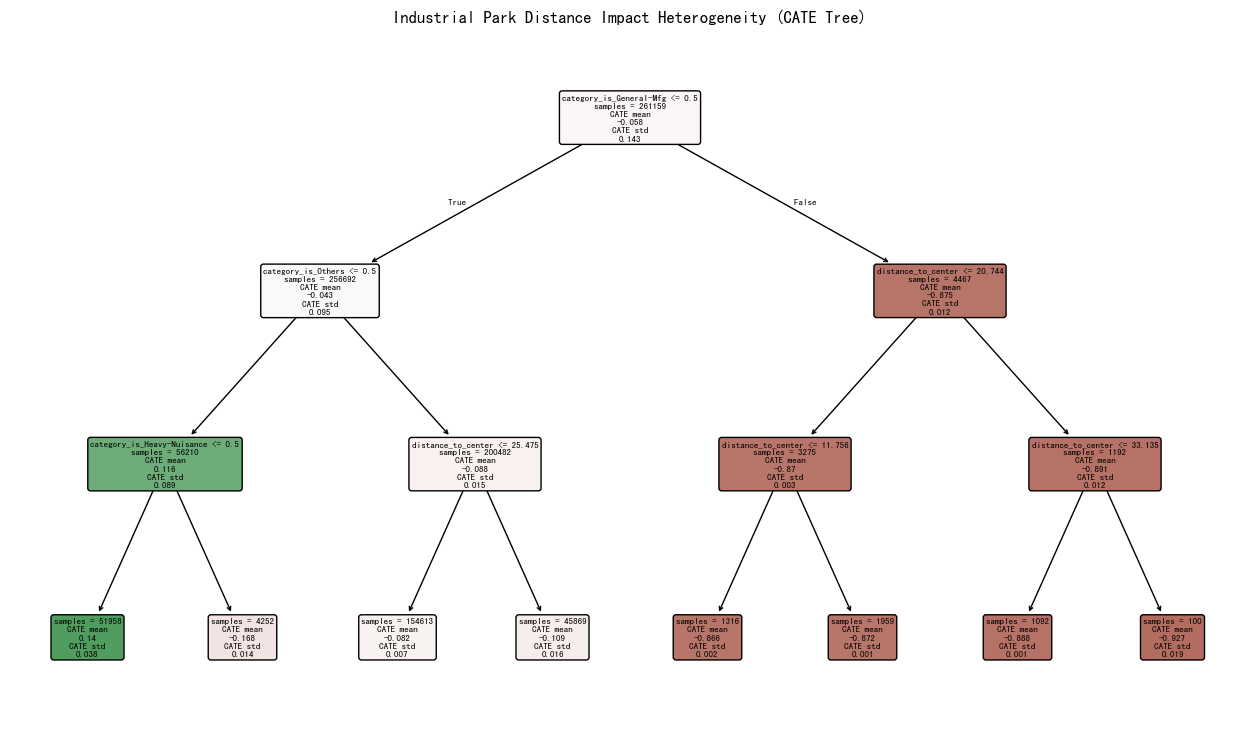

In [ ]:
import warnings
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from econml.dml import LinearDML
from econml.cate_interpreter import SingleTreeCateInterpreter

warnings.filterwarnings('ignore')

est = LinearDML(
    model_y=XGBRegressor(**best_params_y),
    model_t=XGBRegressor(**best_params_t),
    discrete_treatment=False, # 距离是连续变量
    cv=5,                     # 5折交叉拟合
    random_state=42
)

est.fit(Y, T_log, X=X, W=W, inference="statsmodels")

intrp = SingleTreeCateInterpreter(max_depth=3, min_samples_leaf=100)
intrp.interpret(est, X)

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  
plt.figure(figsize=(16, 9))
intrp.plot(feature_names=X_cols) # X_cols 是你传入 X 的特征名称列表
plt.title("Industrial Park Distance Impact Heterogeneity (CATE Tree)")
plt.show()

In [ ]:
print(est.summary())

                              Coefficient Results                               
                           point_estimate stderr zstat  pvalue ci_lower ci_upper
--------------------------------------------------------------------------------
distance_to_center                 -0.001  0.001  -0.93  0.353   -0.003    0.001
category_is_Others                  0.052  0.041  1.261  0.207   -0.029    0.133
category_is_High-Tech               0.254  0.048  5.336    0.0    0.161    0.348
category_is_General-Mfg            -0.737  0.142 -5.206    0.0   -1.014   -0.459
category_is_Heavy-Nuisance         -0.031  0.116 -0.266   0.79   -0.257    0.196
category_is_Modern-Service          0.342  0.074  4.608    0.0    0.196    0.487
                       CATE Intercept Results                       
               point_estimate stderr zstat  pvalue ci_lower ci_upper
--------------------------------------------------------------------
cate_intercept         -0.119  0.045 -2.632  0.008   -0.208    -